In [6]:
# ── Load results (handles both single-file and sharded output) ──────────────
import glob
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_dcsbm_n500.csv"

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

methods = sorted(df["method"].unique())

# Under degree correction the NOMINAL p,q are not what a plain-SBM estimator
# targets -- the empirical block densities are. Both are recorded; everything
# below compares against beta_true_* (empirical) and shows beta_nominal_* only
# as a reference line.
summary = (df.groupby("method")
             .agg(N=("N", "first"), K=("K", "first"),
                  n_sigmas=("sigma", "nunique"), n_reps=("rep", "nunique"),
                  rows=("nmi", "size")))
display(summary)

print(f"\nnominal   betas : within {df['beta_nominal_00'].iloc[0]:.4f}   "
      f"between {df['beta_nominal_01'].iloc[0]:.4f}")
print(f"empirical betas : within {df[['beta_true_00','beta_true_11']].mean().mean():.4f}   "
      f"between {df['beta_true_01'].mean():.4f}   "
      f"(ratio to nominal: {df['beta_true_00'].mean()/df['beta_nominal_00'].iloc[0]:.3f})")
df.head()

Loaded ./results/results_dp_sbm_dcsbm_n500.csv, 200 rows.


,N,K,n_sigmas,n_reps,rows
method,,,,,
edge_flip_vem,500,2,5,20,100
sbm_dpsgd_all_noised,500,2,5,20,100



nominal   betas : within 0.2000   between 0.0200
empirical betas : within 0.2003   between 0.0202   (ratio to nominal: 0.999)


,N,K,dc_sigma,normalize_weights,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,...,beta_nominal_00,beta_nominal_01,beta_nominal_11,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,500,2,0.25,True,0.5,75.261074,0,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.198458,0.019616,0.202345,0.198458,0.019616,0.202345,1.000000
1,500,2,0.25,True,0.5,75.261074,0,sbm_dpsgd_all_noised,70.772185,12.423129,...,0.2,0.02,0.2,0.198458,0.019616,0.202345,0.175809,0.118818,0.150147,0.002994
2,500,2,0.25,True,0.5,75.261074,1,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.198169,0.019552,0.200739,0.200739,0.019552,0.198169,1.000000
3,500,2,0.25,True,0.5,75.261074,1,sbm_dpsgd_all_noised,70.772185,12.423129,...,0.2,0.02,0.2,0.198169,0.019552,0.200739,0.225615,0.011750,0.214631,1.000000
4,500,2,0.25,True,0.5,75.261074,2,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.200353,0.020032,0.199165,0.199165,0.020032,0.200353,1.000000


,rep,N,mean_degree,degree_cv,max_degree,min_degree,weight_mean,weight_cv,lcc_size,lcc_frac,n_components,n_isolated,beta_true_00,beta_true_01,beta_true_11
mean,9.5000,500.0,54.9126,0.2253,102.8000,28.950,1.0,0.1902,500.0,1.0,1.0,0.0,0.1999,0.0202,0.2007
std,5.9161,0.0,0.3682,0.0063,6.6854,1.905,0.0,0.0061,0.0,0.0,0.0,0.0,0.0035,0.0005,0.0032
min,0.0000,500.0,54.1200,0.2120,93.0000,25.000,1.0,0.1799,500.0,1.0,1.0,0.0,0.1910,0.0192,0.1966
max,19.0000,500.0,55.6400,0.2395,120.0000,32.000,1.0,0.2010,500.0,1.0,1.0,0.0,0.2060,0.0213,0.2088


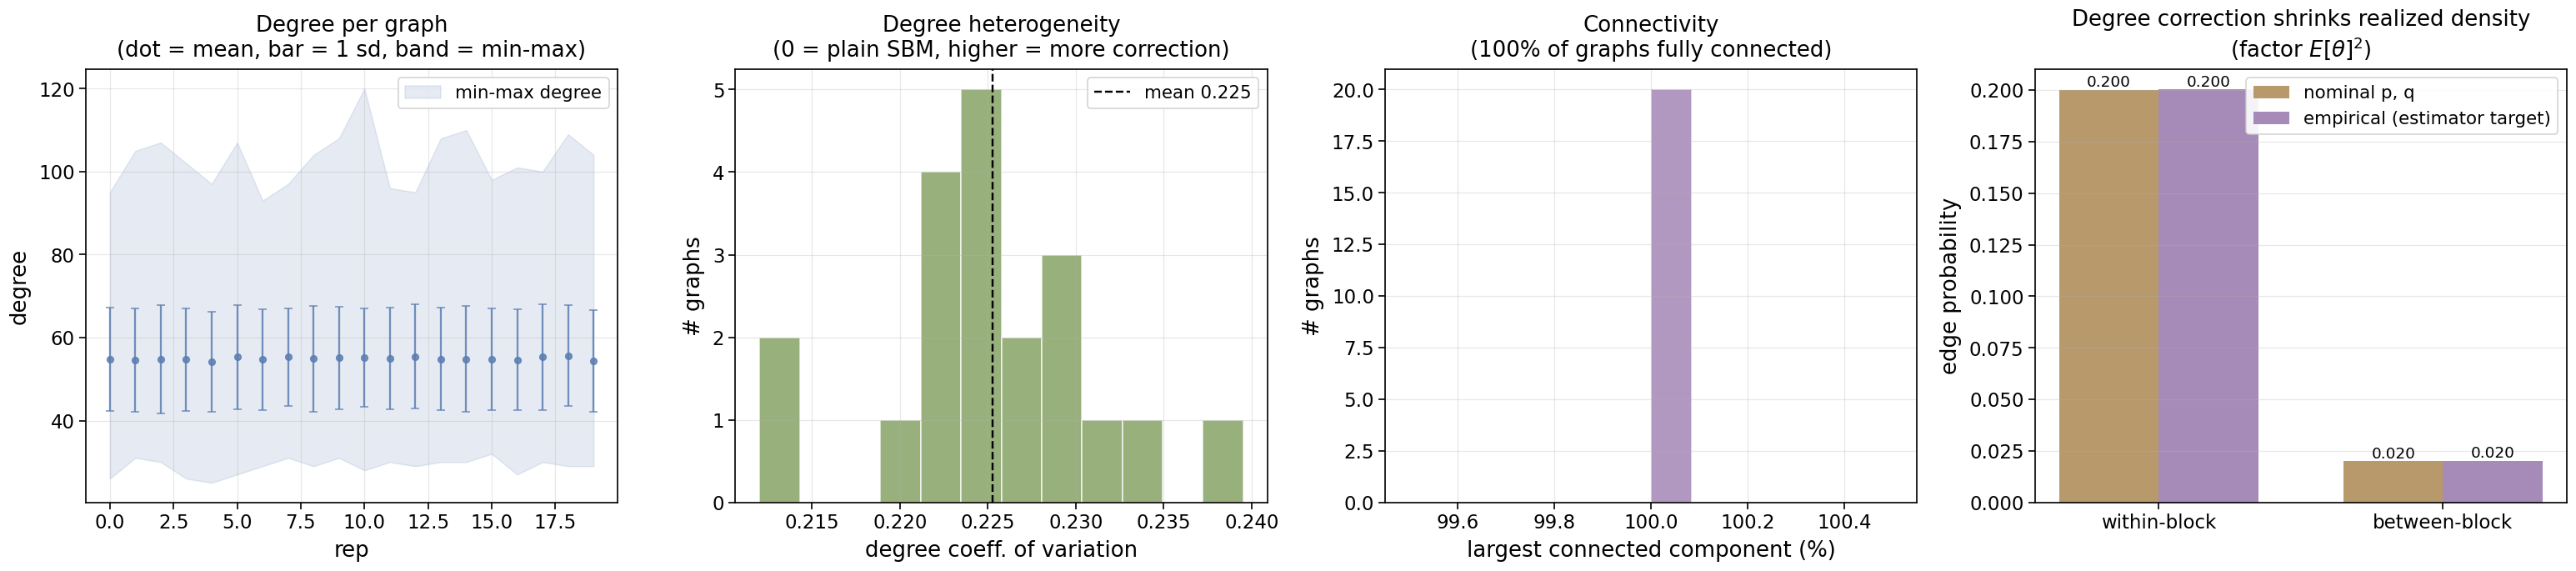

In [7]:
# ── Summary of the generated DC-SBM graphs ─────────────────────────────────
# Dedup note: the rep seed depends on rep only, NOT on sigma, so the same
# graph is reused across every sigma and both methods. Without the
# drop_duplicates each graph would be counted 2*len(SIGMAS) times.
# These panels describe the DATA, not the methods, so they use neutral
# colours rather than the per-method palette -- only the sizing/type comes
# from plot_style.
import numpy as np
import matplotlib.pyplot as plt

from plot_style import apply_style, figsize

apply_style()

graphs = df.drop_duplicates(subset=["rep"])[
    ["rep", "N", "mean_degree", "degree_cv", "max_degree", "min_degree",
     "weight_mean", "weight_cv", "lcc_size", "lcc_frac", "n_components",
     "n_isolated", "beta_true_00", "beta_true_01", "beta_true_11"]
].copy()

display(graphs.describe().loc[["mean", "std", "min", "max"]].round(4))

C_DATA = ["#5B7DB1", "#7E9C5B", "#9C7EB1", "#B18E5B"]
fig, axes = plt.subplots(1, 4, figsize=figsize(21, 4.8))

# (a) degree level and spread
ax = axes[0]
ax.errorbar(graphs["rep"], graphs["mean_degree"],
            yerr=graphs["mean_degree"] * graphs["degree_cv"],
            fmt="o", color=C_DATA[0], alpha=0.85, capsize=3, markersize=5)
ax.fill_between(graphs["rep"], graphs["min_degree"], graphs["max_degree"],
                color=C_DATA[0], alpha=0.15, label="min-max degree")
ax.set_xlabel("rep"); ax.set_ylabel("degree")
ax.set_title("Degree per graph\n(dot = mean, bar = 1 sd, band = min-max)")
ax.grid(alpha=0.3); ax.legend()

# (b) degree heterogeneity -- the whole point of degree correction
ax = axes[1]
ax.hist(graphs["degree_cv"], bins=12, color=C_DATA[1], alpha=0.8, edgecolor="white")
ax.axvline(graphs["degree_cv"].mean(), color="black", linestyle="--",
           linewidth=1.6, label=f"mean {graphs['degree_cv'].mean():.3f}")
ax.set_xlabel("degree coeff. of variation"); ax.set_ylabel("# graphs")
ax.set_title("Degree heterogeneity\n(0 = plain SBM, higher = more correction)")
ax.grid(alpha=0.3); ax.legend()

# (c) connectivity -- dense here, so this should be a degenerate 100% bar
ax = axes[2]
ax.hist(graphs["lcc_frac"] * 100, bins=12, color=C_DATA[2], alpha=0.8, edgecolor="white")
ax.set_xlabel("largest connected component (%)"); ax.set_ylabel("# graphs")
ax.set_title(f"Connectivity\n({(graphs['lcc_frac'] == 1.0).mean():.0%} of graphs fully connected)")
ax.grid(alpha=0.3)

# (d) empirical vs nominal block densities
ax = axes[3]
x = np.arange(2); w = 0.35
emp = [graphs[["beta_true_00", "beta_true_11"]].mean().mean(), graphs["beta_true_01"].mean()]
nom = [df["beta_nominal_00"].iloc[0], df["beta_nominal_01"].iloc[0]]
ax.bar(x - w/2, nom, w, label="nominal p, q", color=C_DATA[3], alpha=0.9)
ax.bar(x + w/2, emp, w, label="empirical (estimator target)",
       color=C_DATA[2], alpha=0.9)
for xi, (a, b) in enumerate(zip(nom, emp)):
    ax.text(xi - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=12)
    ax.text(xi + w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(["within-block", "between-block"])
ax.set_ylabel("edge probability")
ax.set_title("Degree correction shrinks realized density\n(factor $E[\\theta]^2$)")
ax.grid(alpha=0.3, axis="y"); ax.legend()

plt.tight_layout()
plt.show()

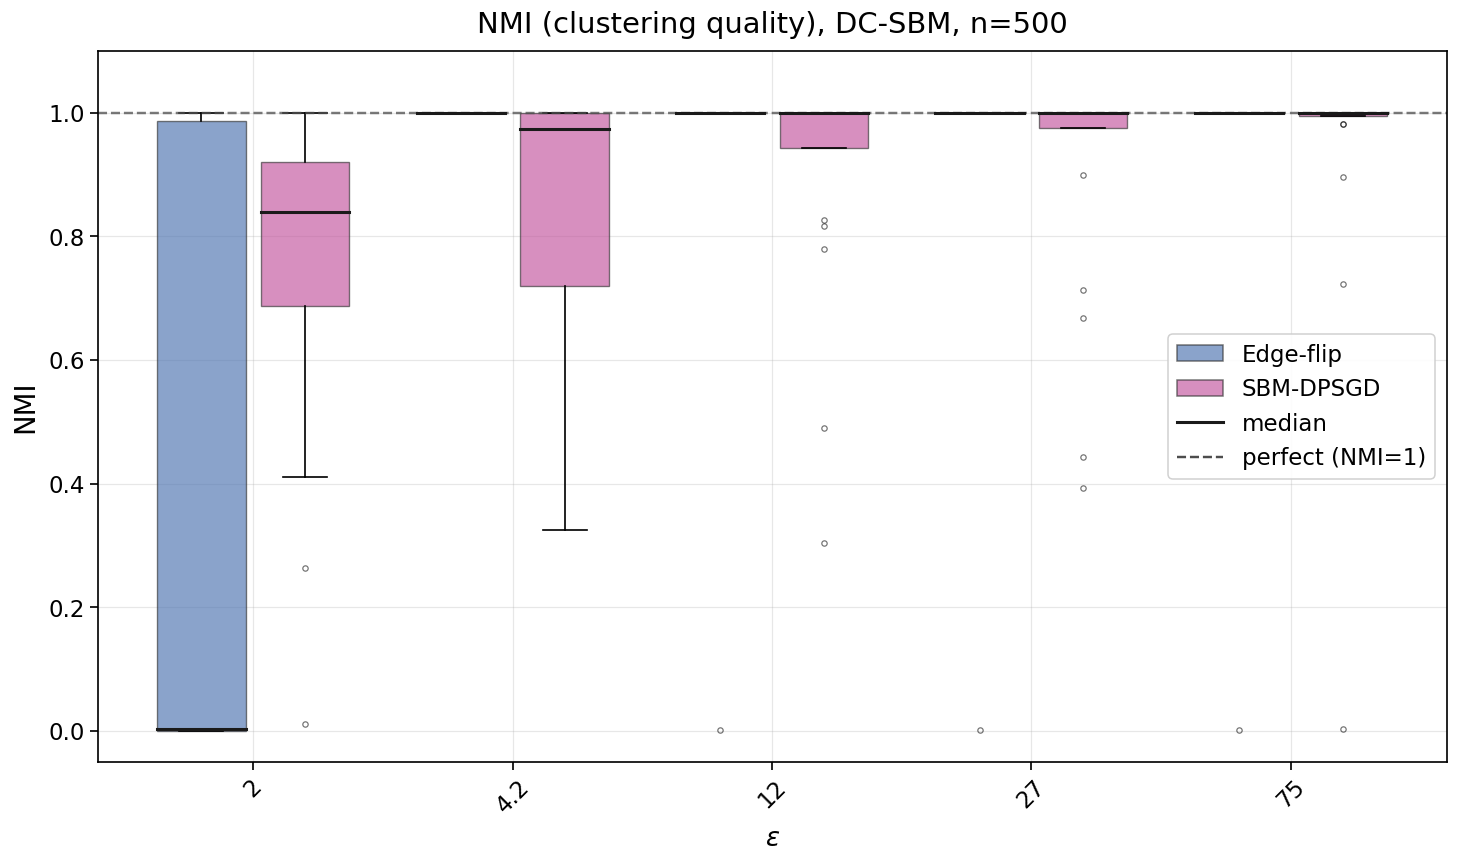

In [8]:
# ── NMI vs epsilon ─────────────────────────────────────────────────────────
# Single large panel of per-epsilon boxplots. (The median-trend/IQR-band panel
# that used to sit alongside it was dropped -- it restated the boxplots'
# medians and quartiles as a line, so it carried no information the boxes did
# not already show.)
# Colours/labels/median style come from plot_style.py so every figure in the
# thesis uses the same colour for the same method.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = order_methods(methods)
eps_vals = sorted(df["epsilon"].unique())

# Per-panel inches before FIG_SCALE -- the single knob for retuning size.
PANEL_W, PANEL_H = 10.0, 6.0

fig, ax = plt.subplots(figsize=figsize(PANEL_W, PANEL_H))

grouped_boxplot(ax, df, "nmi", methods=methods, x_values=eps_vals)
reference_line(ax, 1.0)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("NMI", fontsize=18)
ax.set_title("NMI (clustering quality), DC-SBM, n=500", fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="perfect (NMI=1)"),
]
ax.legend(handles=handles, fontsize=15, loc="best")

plt.tight_layout()
plt.show()

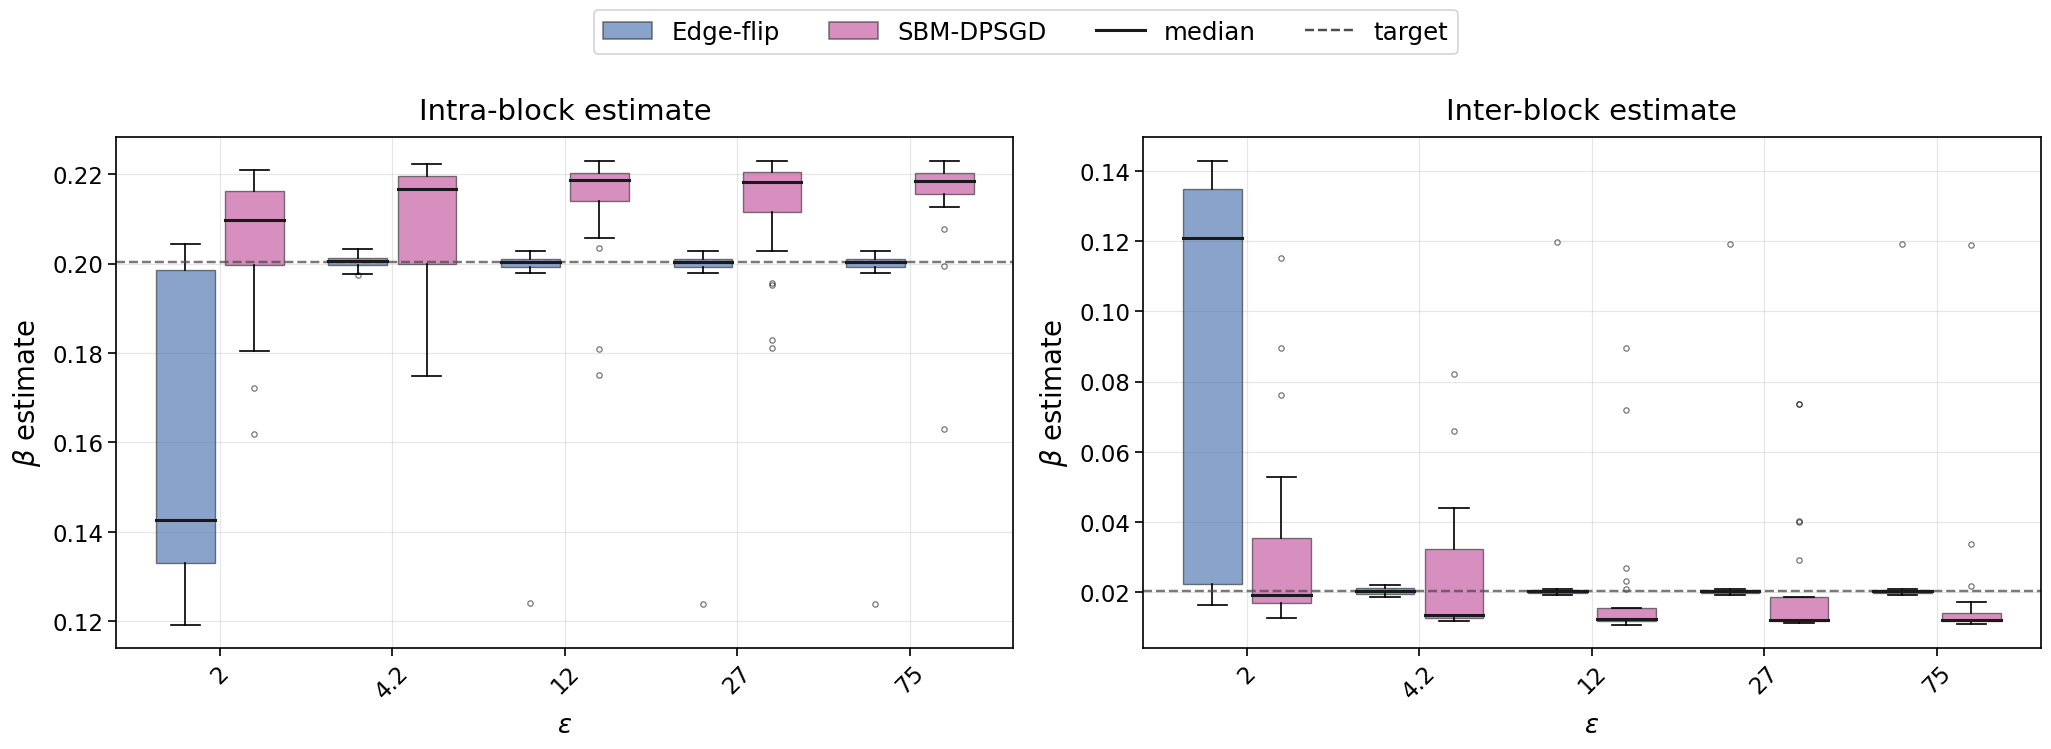

In [9]:
# ── Estimated beta vs epsilon ──────────────────────────────────────────────
# Single graph size (n=500), so no sweep axis for rows -- one row of two large
# panels, intra and inter, sized to match the row-per-N synthetic figures.
# Reference line = target block density. With NORMALIZE_WEIGHTS=True
# (E[theta]=1) the empirical density and the nominal p,q coincide, so a single
# target line suffices -- it is what a plain-SBM estimator aims at.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

methods = order_methods(methods)
eps_vals = sorted(df["epsilon"].unique())

# Per-panel inches before FIG_SCALE -- the single knob for retuning size.
PANEL_W, PANEL_H = 7.0, 5.0

est = df.copy()
est["intra_est"] = est[["beta_est_00", "beta_est_11"]].mean(axis=1)
est["intra_true"] = est[["beta_true_00", "beta_true_11"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=figsize(PANEL_W * 2, PANEL_H))
for ax, (est_col, true_col, title) in zip(axes, [
    ("intra_est", "intra_true", "Intra-block estimate"),
    ("beta_est_01", "beta_true_01", "Inter-block estimate"),
]):
    grouped_boxplot(ax, est, est_col, methods=methods, x_values=eps_vals)
    reference_line(ax, est[true_col].mean())
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$\beta$ estimate", fontsize=18)
    ax.set_title(title, fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="target"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.03))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

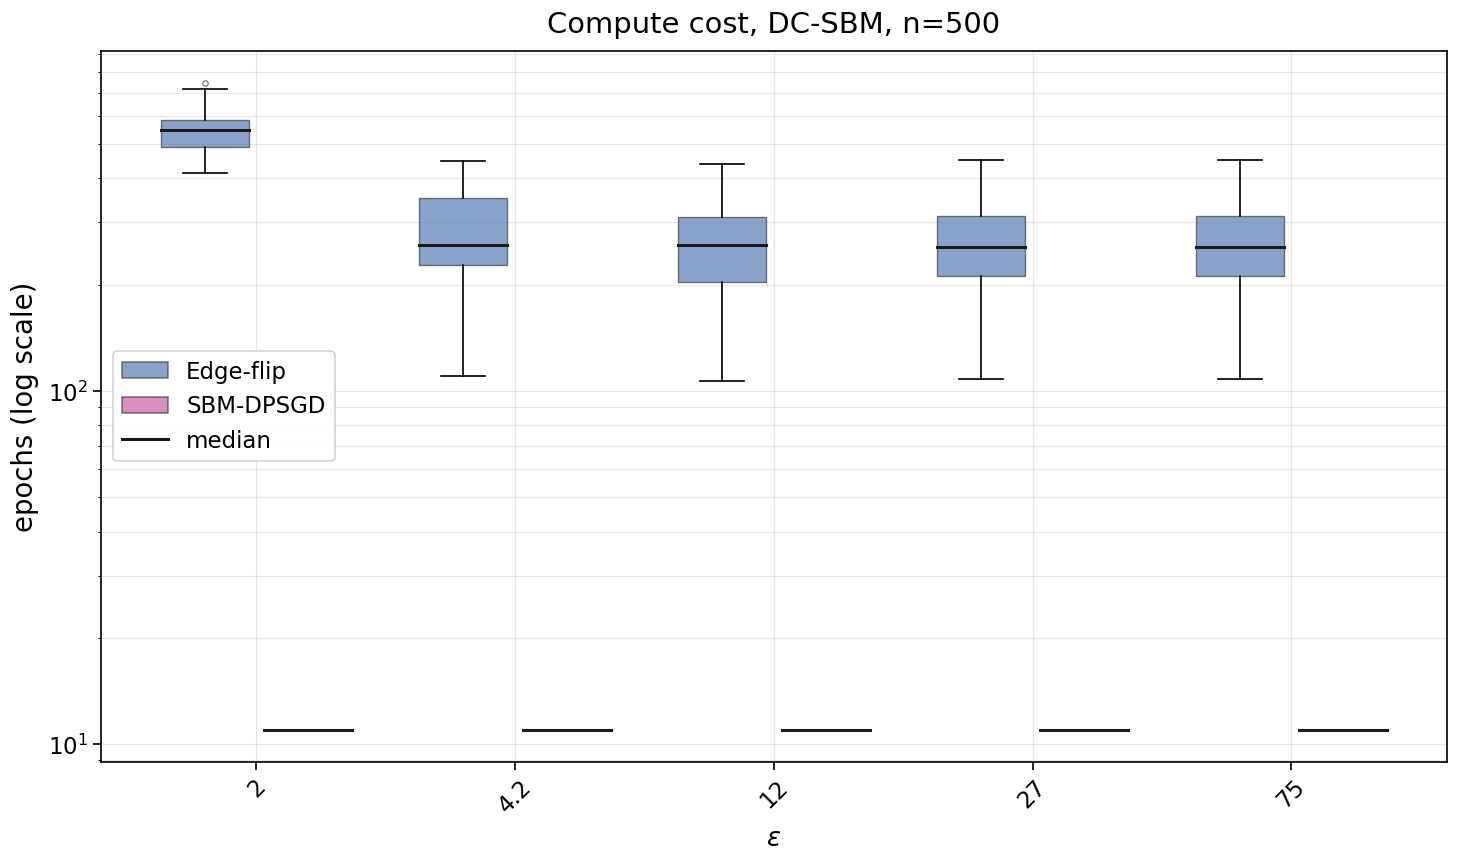

In [10]:
# ── Compute cost (epochs) vs epsilon ───────────────────────────────────────
# Log scale: the two methods differ by ~1-2 orders of magnitude.
# CAVEAT: an epoch is NOT wall-clock comparable across methods -- a VEM epoch
# is a dense O(N^2) matmul pass, an SBM-DPSGD epoch is a sampled
# per-example-autodiff pass.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, BOX_ALPHA, MEDIAN_COLOR)

apply_style()

methods = order_methods(methods)
eps_vals = sorted(df["epsilon"].unique())

PANEL_W, PANEL_H = 10.0, 6.0

fig, ax = plt.subplots(figsize=figsize(PANEL_W, PANEL_H))
grouped_boxplot(ax, df, "epochs", methods=methods, x_values=eps_vals)
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("epochs (log scale)", fontsize=18)
ax.set_title("Compute cost, DC-SBM, n=500", fontsize=19, pad=12)
ax.grid(alpha=0.3, which="both")

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles.append(Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"))
ax.legend(handles=handles, fontsize=15, loc="best")

plt.tight_layout()
plt.show()

In [11]:
# ── Summary table ──────────────────────────────────────────────────────────
import pandas as pd

tbl = df.copy()
tbl["intra_est"] = tbl[["beta_est_00", "beta_est_11"]].mean(axis=1)
tbl["intra_true"] = tbl[["beta_true_00", "beta_true_11"]].mean(axis=1)
tbl["rel_intra"] = (tbl["intra_est"] - tbl["intra_true"]).abs() / tbl["intra_true"]
tbl["rel_inter"] = (tbl["beta_est_01"] - tbl["beta_true_01"]).abs() / tbl["beta_true_01"]

out = (tbl.groupby(["sigma", "epsilon", "method"])
          .agg(nmi_median=("nmi", "median"),
               nmi_iqr=("nmi", lambda s: s.quantile(0.75) - s.quantile(0.25)),
               intra_est_median=("intra_est", "median"),
               inter_est_median=("beta_est_01", "median"),
               rel_intra_median=("rel_intra", "median"),
               rel_inter_median=("rel_inter", "median"),
               epochs_median=("epochs", "median"),
               n=("nmi", "size"))
          .round(4).reset_index().sort_values(["sigma", "method"]))
display(out)

,sigma,epsilon,method,nmi_median,nmi_iqr,intra_est_median,inter_est_median,rel_intra_median,rel_inter_median,epochs_median,n
0,0.5,75.261074,edge_flip_vem,1.0000,0.0000,0.2002,0.0203,0.0000,0.0000,256.0,20
1,0.5,75.261074,sbm_dpsgd_all_noised,1.0000,0.0047,0.2184,0.0121,0.0930,0.3973,11.0,20
2,1.0,27.449963,edge_flip_vem,1.0000,0.0000,0.2002,0.0203,0.0000,0.0000,256.0,20
3,1.0,27.449963,sbm_dpsgd_all_noised,1.0000,0.0252,0.2183,0.0121,0.0941,0.4094,11.0,20
4,2.0,11.732852,edge_flip_vem,1.0000,0.0000,0.2003,0.0203,0.0000,0.0004,259.0,20
5,2.0,11.732852,sbm_dpsgd_all_noised,1.0000,0.0574,0.2187,0.0122,0.0945,0.4022,11.0,20
6,5.0,4.150006,edge_flip_vem,1.0000,0.0000,0.2005,0.0203,0.0017,0.0242,259.0,20
7,5.0,4.150006,sbm_dpsgd_all_noised,0.9738,0.2808,0.2168,0.0134,0.0885,0.3870,11.0,20
8,10.0,1.995318,edge_flip_vem,0.0037,0.9856,0.1427,0.1208,0.2838,4.9050,547.0,20
9,10.0,1.995318,sbm_dpsgd_all_noised,0.8398,0.2319,0.2098,0.0193,0.0706,0.3200,11.0,20
